In [1]:
import subprocess, sys, os, importlib

# -- 0. Clone / pull repo ------------------------------------
REPO_URL = 'https://github.com/bishnt/PINN_for_transient_stability.git'
REPO_DIR = '/content/pinn-transient-stability'

if not os.path.exists(REPO_DIR):
    subprocess.run(['git', 'clone', REPO_URL, REPO_DIR], check=True)
else:
    subprocess.run(['git', 'pull'], cwd=REPO_DIR, check=True)

subprocess.run(
    [sys.executable, '-m', 'pip', 'install', '-q',
     'torch', 'numpy', 'scipy', 'matplotlib', 'tqdm', 'scikit-learn'],
    check=True
)

sys.path.insert(0, os.path.join(REPO_DIR, 'src'))
os.chdir(REPO_DIR)

# -- Print latest commits (useful to confirm stale-import issues) --
result = subprocess.run(
    ['git', 'log', '--oneline', '-3'],
    cwd=REPO_DIR, capture_output=True, text=True
)
print(f'[git] Latest commits:\n{result.stdout}')
print(f'[OK] Working directory: {os.getcwd()}')

# -- Force reload all project modules after pull --------------
for mod_name in ['swing_equation', 'data_generator', 'model', 'loss', 'trainer', 'stability_analysis']:
    if mod_name in sys.modules:
        importlib.reload(sys.modules[mod_name])

[git] Latest commits:
8d7008d update: new model
64a4e29 Merge branch 'main' of https://github.com/bishnt/PINN_for_transient_stability
3eb1d84 add: stability analysis notebook

[OK] Working directory: /content/pinn-transient-stability


In [2]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt

from swing_equation import SMIBParameters
from data_generator import PINNDataGenerator
from model import PINN, count_parameters
from stability_analysis import StabilityAnalyzer

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# -- 1. Load trained model ------------------------------------
MODEL_PATH = 'models/pinn_trained-1.pt'

if os.path.exists(MODEL_PATH):
    checkpoint = torch.load(MODEL_PATH, map_location=device)
    model = PINN(n_hidden_layers=4, n_neurons=64)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(device)
    model.eval()
    print(f'[OK] Loaded trained model from {MODEL_PATH}')
    print(f'     Trainable parameters: {count_parameters(model):,}')
else:
    print(f'[ERROR] Model file not found: {MODEL_PATH}')
    print('Please train the model first using the training notebook.')
    raise FileNotFoundError(f'Model not found: {MODEL_PATH}')

Using device: cuda
[OK] Loaded trained model from models/pinn_trained-1.pt
     Trainable parameters: 12,738


In [3]:
# -- 2. Setup parameters for stability analysis -------------
# Physics parameters (should match training)
params = SMIBParameters(H=5.0, D=0.05, Pm=0.8, Pmax=2.1)

# Fault parameters
FAULT_START = 0.1
FAULT_END = 0.2
T_TOTAL = 2.0

# Stability threshold (degrees)
DELTA_THRESHOLD = 120.0

# Initialize stability analyzer
analyzer = StabilityAnalyzer(model, params, device)
print(f'[OK] Stability analyzer initialized')
print(f'     Equilibrium angle: {np.degrees(params.delta_eq):.2f} degrees')

[OK] Stability analyzer initialized
     Equilibrium angle: 22.39 degrees


In [4]:
# -- 3. Generate reference trajectory for accuracy check ----
gen = PINNDataGenerator(params, seed=42)
traj = gen.generate_reference_trajectory(
    fault_start=FAULT_START,
    fault_end=FAULT_END,
    t_total=T_TOTAL
)

print(f'[OK] Reference trajectory generated')
print(f'     Time span: 0 to {T_TOTAL}s')
print(f'     Fault window: {FAULT_START}s to {FAULT_END}s')

[OK] Reference trajectory generated
     Time span: 0 to 2.0s
     Fault window: 0.1s to 0.2s


In [5]:
# -- 4. Evaluate PINN accuracy against RK4 -----------------
results = analyzer.evaluate_accuracy(traj, n_points=500)

print('\n=== Accuracy Metrics ===')
print(f'MAE delta: {np.degrees(results["mae_delta"]):.4f} degrees')
print(f'MAE omega: {results["mae_omega"]:.4f} rad/s')
print(f'RMSE delta: {np.degrees(results["rmse_delta"]):.4f} degrees')
print(f'RMSE omega: {results["rmse_omega"]:.4f} rad/s')
print('========================\n')


=== Accuracy Metrics ===
MAE delta: 0.0962 degrees
MAE omega: 376.9915 rad/s
RMSE delta: 0.4022 degrees
RMSE omega: 376.9915 rad/s



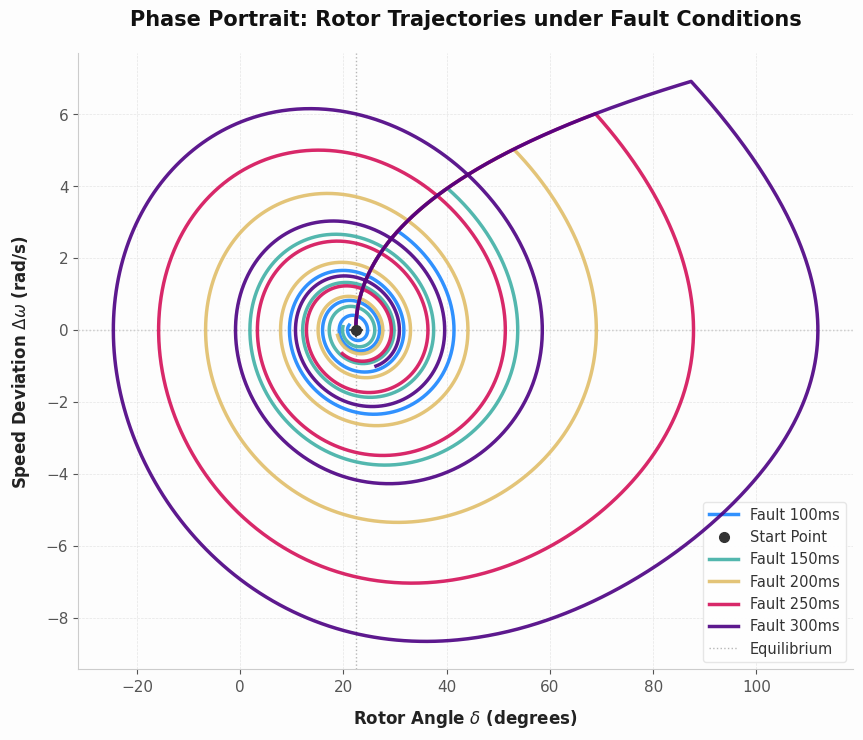

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Set clean, modern typography defaults
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['text.color'] = '#333333'

fig, ax = plt.subplots(figsize=(10, 8), facecolor='#FDFDFD')
ax.set_facecolor('#FDFDFD')

# Fault durations
fault_times = [0.1, 0.15, 0.2, 0.25, 0.3]

# A professional, progressive palette (cool blue to intense purple/crimson)
colors_list = ['#1A85FF', '#40B0A6', '#E1BE6A', '#D41159', '#4B0082']

for i, (ft, color) in enumerate(zip(fault_times, colors_list)):
    traj = gen.generate_reference_trajectory(
        fault_start=0.1,
        fault_end=0.1+ft,
        t_total=3.0
    )
    label = f'Fault {ft*1000:.0f}ms'

    delta_deg = np.degrees(traj['delta'])
    omega_dev = traj['omega'] - params.omega0

    # Plot trajectories with slight transparency to handle overlapping spirals elegantly
    ax.plot(delta_deg, omega_dev,
            color=color, linewidth=2.5, label=label, alpha=0.9, zorder=5+i)

    # Plot the initial starting point exactly once
    if i == 0:
        ax.plot(delta_deg[0], omega_dev[0],
                'o', color='#333333', markersize=7, label='Start Point', zorder=10)

# Equilibrium lines - clean, subtle dotted indicators
ax.axhline(0, color='#888888', linewidth=1, linestyle=':', alpha=0.6, zorder=1)
eq_delta = np.degrees(params.delta_eq)
ax.axvline(eq_delta, color='#888888', linewidth=1, linestyle=':', alpha=0.6, label='Equilibrium', zorder=1)

# Highlight equilibrium center with a precise crosshair symbol
ax.plot(eq_delta, 0, '+', color='#555555', markersize=10, markeredgewidth=1.5, zorder=2)

# Professional axis labels using proper math symbols
ax.set_xlabel(r'Rotor Angle $\delta$ (degrees)', fontsize=12, fontweight='bold', labelpad=10, color='#222222')
ax.set_ylabel(r'Speed Deviation $\Delta\omega$ (rad/s)', fontsize=12, fontweight='bold', labelpad=10, color='#222222')
ax.set_title('Phase Portrait: Rotor Trajectories under Fault Conditions', fontsize=15, fontweight='bold', pad=20, color='#111111')

# Modern styling for grid and borders (spines)
ax.grid(True, linestyle='--', linewidth=0.5, color='#E0E0E0', alpha=0.8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')
ax.tick_params(colors='#555555', labelsize=11)

# Clean legend formatting
ax.legend(loc='lower right', frameon=True, facecolor='#FFFFFF', edgecolor='#E5E5E5', framealpha=0.95, fontsize=10.5)

# Save with crisp, publication-quality resolution
plt.savefig('results/plots/phase_portrait.png', dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

In [8]:
# -- 6. Compute stability map using PINN (fast screening) --
# Define parameter sweep ranges
fault_durations = np.linspace(0.05, 0.5, 20)  # 50ms to 500ms
initial_angles = np.linspace(np.radians(10), np.radians(80), 30)  # 10 to 80 degrees

print(f'Computing PINN-based stability map...')
print(f'  Fault durations: {len(fault_durations)} points ({fault_durations[0]*1000:.0f}ms to {fault_durations[-1]*1000:.0f}ms)')
print(f'  Initial angles: {len(initial_angles)} points ({np.degrees(initial_angles[0]):.0f}° to {np.degrees(initial_angles[-1]):.0f}°)')

# Compute using PINN for fast screening
stability_map_pinn = analyzer.compute_stability_map(
    fault_durations,
    initial_angles,
    t_total=T_TOTAL,
    delta_threshold_deg=DELTA_THRESHOLD,
    use_pinn=True
)

print(f'[OK] PINN stability map computed')
print(f'     Stable regions: {stability_map_pinn.sum()} / {stability_map_pinn.size}')

Computing PINN-based stability map...
  Fault durations: 20 points (50ms to 500ms)
  Initial angles: 30 points (10° to 80°)
Computing stability map...
[OK] PINN stability map computed
     Stable regions: 287.0 / 600


In [9]:
# -- 7. Compute stability map using RK4 (reference) ---------
print('Computing RK4-based stability map (this may take a while)...')

# Use fewer points for RK4 since it's slower
fault_durations_rk4 = np.linspace(0.05, 0.5, 10)  # Fewer points for speed
initial_angles_rk4 = np.linspace(np.radians(10), np.radians(80), 15)

stability_map_rk4 = analyzer.compute_stability_map(
    fault_durations_rk4,
    initial_angles_rk4,
    t_total=T_TOTAL,
    delta_threshold_deg=DELTA_THRESHOLD,
    use_pinn=False  # Use RK4
)

print(f'[OK] RK4 stability map computed')
print(f'     Stable regions: {stability_map_rk4.sum()} / {stability_map_rk4.size}')

Computing RK4-based stability map (this may take a while)...
Computing stability map...
[OK] RK4 stability map computed
     Stable regions: 71.0 / 150


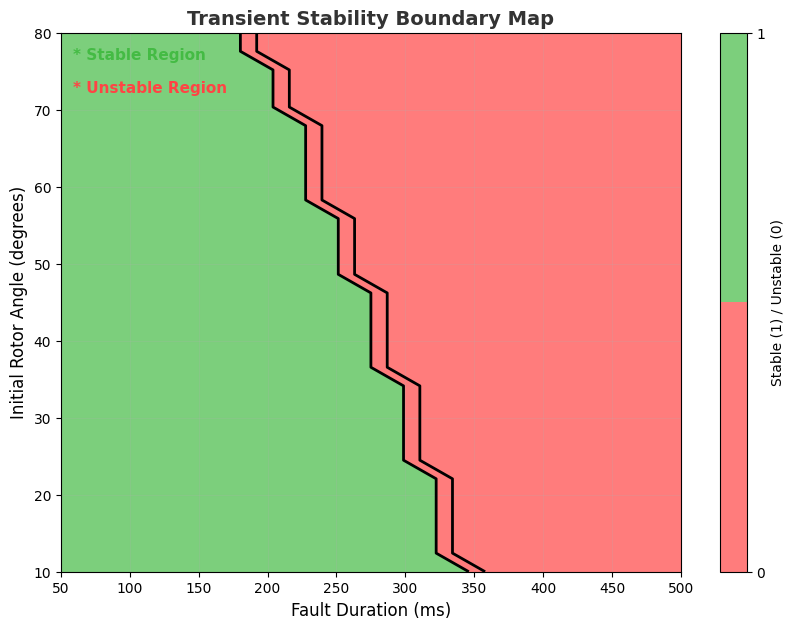

In [10]:
# -- 8. Plot PINN stability map -----------------------------
analyzer.plot_stability_map(
    fault_durations,
    initial_angles,
    stability_map_pinn,
    save_path='results/plots/stability_map_pinn.png'
)

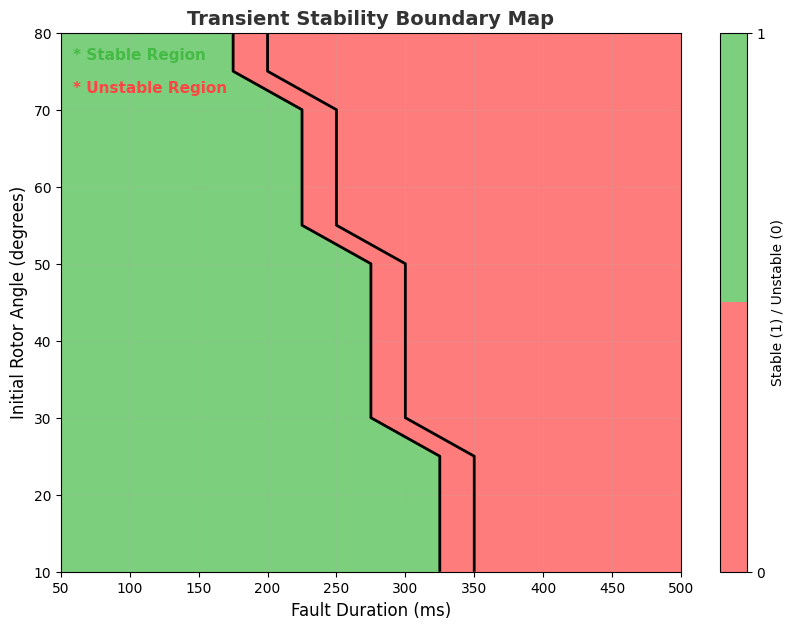

In [11]:
# -- 9. Plot RK4 stability map (reference) ------------------
analyzer.plot_stability_map(
    fault_durations_rk4,
    initial_angles_rk4,
    stability_map_rk4,
    save_path='results/plots/stability_map_rk4.png'
)

In [12]:
# -- 10. Compare stability maps ----------------------------
# Interpolate RK4 map to same grid as PINN for comparison
from scipy.interpolate import RegularGridInterpolator

# Create interpolator for RK4 map
interp_rk4 = RegularGridInterpolator(
    (initial_angles_rk4, fault_durations_rk4),
    stability_map_rk4,
    method='nearest',
    bounds_error=False,
    fill_value=0
)

# Interpolate to PINN grid
grid_angles, grid_durations = np.meshgrid(initial_angles, fault_durations, indexing='ij')
points = np.column_stack([grid_angles.ravel(), grid_durations.ravel()])
stability_map_rk4_interp = interp_rk4(points).reshape(stability_map_pinn.shape)

# Compute agreement
agreement = np.mean(stability_map_pinn == stability_map_rk4_interp)
print(f'\n=== Stability Map Comparison ===')
print(f'Agreement between PINN and RK4: {agreement*100:.1f}%')
print('=================================\n')


=== Stability Map Comparison ===
Agreement between PINN and RK4: 97.8%



/tmp/ipykernel_1236/1052399122.py:30: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  agreement_patch = mpatches.Patch(
/tmp/ipykernel_1236/1052399122.py:33: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  disagreement_patch = mpatches.Patch(


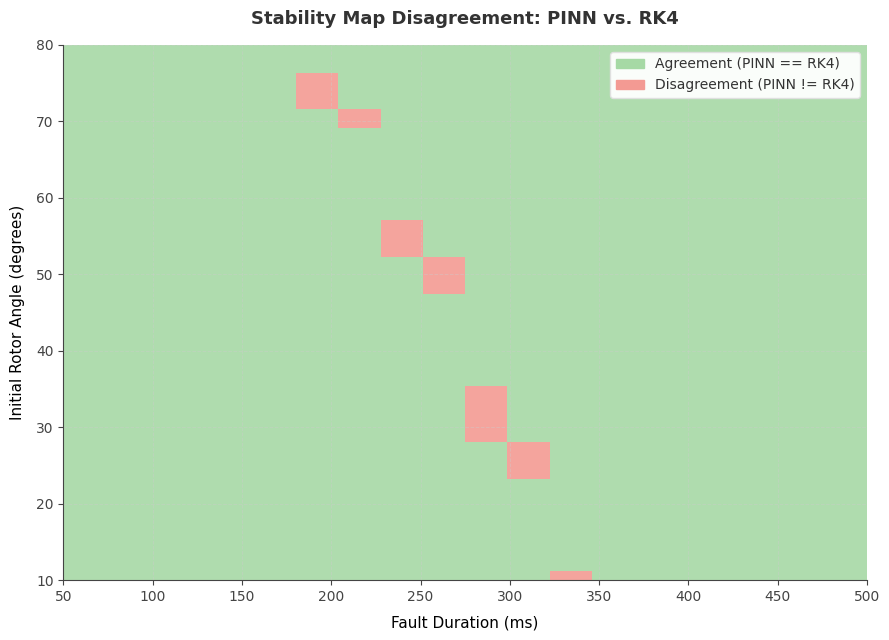

[OK] Stability evaluation complete!
Results saved to results/plots/


In [15]:
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np

# 1. Figure setup with professional dimensions and clean layout
fig, ax = plt.subplots(figsize=(9, 6.5))

# 2. Muted, academic color palette (Green = Agreement, Red = Disagreement)
# Index 0 -> Muted Sage Green (#A6D9A5), Index 1 -> Muted Coral Red (#F39A93)
colors = ["#A6D9A5", "#F39A93"]
cmap = LinearSegmentedColormap.from_list("stability_diff", colors, N=2)

# Compute binary difference map (0.0 for agreement, 1.0 for disagreement)
diff_map = (stability_map_pinn != stability_map_rk4_interp).astype(float)

# 3. Plot discrete pixels to map binary coordinates exactly without interpolation artifacts
im = ax.pcolormesh(
    fault_durations * 1000,
    np.degrees(initial_angles),
    diff_map,
    cmap=cmap,
    shading="nearest",
    vmin=0,
    vmax=1,
    alpha=0.9,
)

# 4. Clean, discrete legend for categorical binary outcomes
agreement_patch = mpatches.Patch(
    color=colors[0], label="Agreement (PINN == RK4)", edgecolor="none"
)
disagreement_patch = mpatches.Patch(
    color=colors[1], label="Disagreement (PINN != RK4)", edgecolor="none"
)
ax.legend(
    handles=[agreement_patch, disagreement_patch],
    loc="upper right",
    frameon=True,
    framealpha=0.95,
    facecolor="white",
    edgecolor="#E0E0E0",
    fontsize=10,
)

# 5. Professional typography and descriptive labels
ax.set_xlabel("Fault Duration (ms)", fontsize=11, fontweight="medium", labelpad=8)
ax.set_ylabel(
    "Initial Rotor Angle (degrees)", fontsize=11, fontweight="medium", labelpad=8
)
ax.set_title(
    "Stability Map Disagreement: PINN vs. RK4",
    fontsize=13,
    fontweight="bold",
    pad=15,
)

# 6. Subtle background grid that aligns nicely with pcolormesh boundaries
ax.grid(True, linestyle="--", color="#CCCCCC", alpha=0.4, linewidth=0.7)

# 7. Clean up structural frame lines (spines)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.spines["left"].set_color("#444444")
ax.spines["bottom"].set_color("#444444")
ax.tick_params(colors="#444444", labelsize=10)

# Ensure the plot limits clip perfectly to your coordinate ranges
ax.set_xlim(fault_durations.min() * 1000, fault_durations.max() * 1000)
ax.set_ylim(np.degrees(initial_angles).min(), np.degrees(initial_angles).max())

# 8. Save with tight margins and publication-grade resolution (300 DPI)
plt.tight_layout()
plt.savefig("results/plots/stability_map_difference.png", dpi=300, bbox_inches="tight")
plt.show()

print("[OK] Stability evaluation complete!")
print("Results saved to results/plots/")

### Boundary Map Parameters

Let's review the ranges of the parameters used to generate the stability maps. These ranges define the boundaries of the plots.

In [14]:
print('--- PINN Stability Map Parameters ---')
print(f'Fault Durations: {fault_durations.min()*1000:.1f}ms to {fault_durations.max()*1000:.1f}ms')
print(f'Initial Angles: {np.degrees(initial_angles.min()):.1f}° to {np.degrees(initial_angles.max()):.1f}°')

print('\n--- RK4 Stability Map Parameters ---')
print(f'Fault Durations: {fault_durations_rk4.min()*1000:.1f}ms to {fault_durations_rk4.max()*1000:.1f}ms')
print(f'Initial Angles: {np.degrees(initial_angles_rk4.min()):.1f}° to {np.degrees(initial_angles_rk4.max()):.1f}°')

--- PINN Stability Map Parameters ---
Fault Durations: 50.0ms to 500.0ms
Initial Angles: 10.0° to 80.0°

--- RK4 Stability Map Parameters ---
Fault Durations: 50.0ms to 500.0ms
Initial Angles: 10.0° to 80.0°


### Explanation of Boundary Maps

The stability maps are visualizations where the X-axis typically represents the **Fault Duration** (how long the fault persists) and the Y-axis represents the **Initial Rotor Angle** (the starting angle of the generator rotor).

*   **Fault Duration (X-axis):** This parameter determines how long the system is under fault conditions. Longer fault durations generally lead to less stable operation.
*   **Initial Rotor Angle (Y-axis):** This represents the pre-fault operating point of the synchronous machine. Larger initial angles (closer to the stability limit) indicate a more susceptible system to instability.

The maps color-code regions as 'stable' or 'unstable' based on whether the system returns to a stable operating point after a fault, given specific fault duration and initial rotor angle. The 'boundaries' you refer to are the edges of these ranges, which define the scope of the analysis. The interpolation of the RK4 map to the PINN grid is done to enable a direct comparison of stability predictions across the same parameter space.